# Preprocessing Final — HargaWatch (Silver Layer)

Notebook ini **menggantikan** `preprocessing_pasar.ipynb` & `preprocessing_produsen.ipynb` lama,
dan memperbaiki seluruh 6 temuan audit (`panduan_persiapan_database_hargawatch.md`):

| # | Temuan audit | Perbaikan di sini |
|---|---|---|
| 1 | `ffill(3)+interpolate(7)` → *lookahead bias* & harga desimal pecahan | **ffill murni** + `round(0)` rupiah bulat |
| 2 | Masih ada `NaN` di kolom target | `harga_imputasi` **0 NaN** |
| 3 | Pasar Genteng absen dari preprocessing | **6 pasar** diproses |
| 4 | `harga_kemarin` statis → desinkron | Kolom **dihapus**; hitung `LAG()` saat analytics |
| 5 | Produsen tanpa fitur kalender | Kalender + dual-price untuk produsen |
| 6 | *Leading NaN* di awal deret | Dipangkas per komoditas sebelum entri valid pertama |

**Dual-price column** (prinsip dokumen audit):
- `harga_asli` — murni lapangan, `0` diubah jadi NULL (nullable)
- `harga_imputasi` — hasil ffill murni, rupiah bulat, NOT NULL
- `is_imputed` — flag transparansi

Sumber kebenaran logika: `scripts/preprocessing_final.py` (notebook ini menjalankan + memverifikasi).

In [1]:
import sys, os
sys.path.append(os.path.abspath("../scripts"))

import pandas as pd
import matplotlib.pyplot as plt

import preprocessing_final as pf

pd.set_option("display.width", 140)
print("pandas", pd.__version__)

pandas 2.3.3


## 1. Jalankan pipeline

In [2]:
pf.main()

dim_kalender.csv : 2439 baris


Pasar Tambahrejo         84217 baris | 35 komoditas (buang: Ikan Cakalang, Ikan Tuna)


Pasar Wonokromo          80267 baris | 34 komoditas (buang: Ikan Cakalang, Ikan Kembung, Ikan Tuna)


Pasar Genteng            86656 baris | 36 komoditas (buang: Ikan Cakalang)


Pasar Pucang Anom        89091 baris | 37 komoditas


Pasar Keputran           84174 baris | 36 komoditas (buang: Ikan Tuna)


Pasar Soponyono          52692 baris | 37 komoditas
dim_pasar.csv    : 6 baris


fact_harga_pasar.csv : 477097 baris
dim_komoditas.csv : 37 komoditas
fact_harga_produsen.csv : 4872 baris

=== Verifikasi audit ===
harga_imputasi NaN : 0 (harus 0)
Nilai desimal      : 0 (harus 0)
Pasar terproses    : 6 (harus 6)
Baris is_imputed   : 18131 (3.8%)


## 2. Muat hasil & verifikasi otomatis

In [3]:
fact = pd.read_csv("../data/processed/fact_harga_pasar.csv", parse_dates=["tanggal"])
prod = pd.read_csv("../data/processed/fact_harga_produsen.csv", parse_dates=["tanggal"])
dim_kom = pd.read_csv("../data/processed/dim_komoditas.csv")
dim_pasar = pd.read_csv("../data/processed/dim_pasar.csv")
dim_kal = pd.read_csv("../data/processed/dim_kalender.csv", parse_dates=["tanggal"])

assert fact["harga_imputasi"].isna().sum() == 0, "Masih ada NaN (temuan #2)"
assert (fact["harga_imputasi"] % 1 != 0).sum() == 0, "Masih ada desimal (temuan #1)"
assert fact["pasar_id"].nunique() == 6, "Genteng belum masuk (temuan #3)"
assert "harga_kemarin" not in fact.columns, "harga_kemarin masih ada (temuan #4)"
assert {"is_ramadan", "is_libur_nasional"}.issubset(prod.columns), "Kalender produsen (temuan #5)"
assert (fact["harga_asli"] == 0).sum() == 0, "0 seharusnya sudah jadi NULL"
print("Semua assertion audit lolos ✓")

Semua assertion audit lolos ✓


## 3. Ringkasan per pasar

In [4]:
ringkas = (fact.groupby("pasar_id")
             .agg(n_hari=("tanggal", "nunique"),
                  n_komoditas=("komoditas_id", "nunique"),
                  pct_imputed=("is_imputed", lambda s: round(100 * s.mean(), 1)))
             .reset_index()
             .merge(dim_pasar[["pasar_id", "nama_pasar"]], on="pasar_id"))
ringkas

,pasar_id,n_hari,n_komoditas,pct_imputed,nama_pasar
0,1,2435,35,4.5,Pasar Tambahrejo
1,2,2435,34,2.8,Pasar Wonokromo
2,3,2435,36,4.5,Pasar Genteng
3,4,2435,37,0.2,Pasar Pucang Anom
4,5,2435,36,8.2,Pasar Keputran
5,146,1428,37,2.4,Pasar Soponyono


## 4. Bukti perbaikan temuan #1 — gap Minyak Goreng 2022

Dulu: 30 hari NaN + harga desimal pecahan hasil interpolasi.
Sekarang: ffill murni, flag `is_imputed=True`, rupiah bulat.

In [5]:
gap = fact[(fact["komoditas"] == "Minyak Goreng Kemasan Premium")
           & (fact["pasar_id"] == 4)  # Pucang Anom
           & (fact["tanggal"].between("2022-04-15", "2022-05-05"))]
gap[["tanggal", "harga_asli", "harga_imputasi", "is_imputed"]].head(10)

,tanggal,harga_asli,harga_imputasi,is_imputed
337200,2022-04-15,NaN,25000,True
337201,2022-04-16,NaN,25000,True
337202,2022-04-17,NaN,25000,True
337203,2022-04-18,NaN,25000,True
337204,2022-04-19,NaN,25000,True
337205,2022-04-20,NaN,25000,True
337206,2022-04-21,NaN,25000,True
337207,2022-04-22,NaN,25000,True
337208,2022-04-23,NaN,25000,True
337209,2022-04-24,NaN,25000,True


## 5. Visual: deret harga + titik imputasi

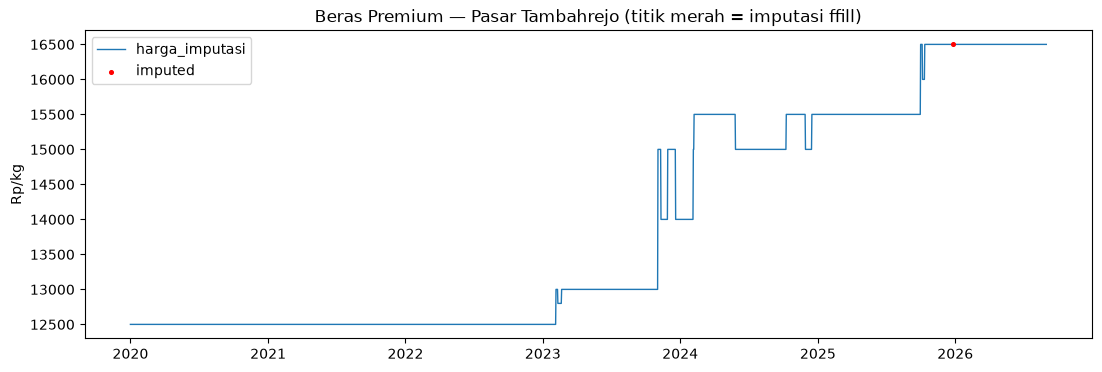

In [6]:
s = fact[(fact["pasar_id"] == 1) & (fact["komoditas"] == "Beras Premium")].set_index("tanggal")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s.index, s["harga_imputasi"], lw=1, label="harga_imputasi")
imp = s[s["is_imputed"]]
ax.scatter(imp.index, imp["harga_imputasi"], s=7, color="red", label="imputed", zorder=3)
ax.set_title("Beras Premium — Pasar Tambahrejo (titik merah = imputasi ffill)")
ax.set_ylabel("Rp/kg")
ax.legend()
plt.show()

## 6. Preview tabel dimensi

In [7]:
display(dim_pasar)
display(dim_kom.head(10))

,pasar_id,nama_pasar,tipe_pasar
0,1,Pasar Tambahrejo,Pasar Tradisional Ritel
1,2,Pasar Wonokromo,Pasar Tradisional Ritel
2,3,Pasar Genteng,Pasar Tradisional Ritel
3,4,Pasar Pucang Anom,Pasar Tradisional Ritel
4,5,Pasar Keputran,Pasar Induk Grosir
5,146,Pasar Soponyono,Pasar Tradisional Ritel


,komoditas_id,komoditas,grup,satuan
0,2,Beras Premium,BERAS,kg
1,4,Beras Medium,BERAS,kg
2,7,Gula Kristal Putih,GULA,kg
3,10,Minyak Goreng Curah,MINYAK GORENG,kg
4,12,Daging Sapi Paha Belakang,DAGING,kg
5,13,Daging Ayam Ras,DAGING,kg
6,14,Daging Ayam Kampung,DAGING,ekor
7,16,Telur Ayam Ras,TELUR AYAM,kg
8,17,Telur Ayam Kampung,TELUR AYAM,kg
9,20,Susu Kental Manis Merk Bendera,SUSU,370 gr/kl


## 7. Skema database target

| File | Tabel |
|---|---|
| `dim_pasar.csv` | `dim_pasar` (+ lat/lon dari koordinat_pasar.csv) |
| `dim_komoditas.csv` | `dim_komoditas` |
| `dim_kalender.csv` | `dim_kalender` |
| `fact_harga_pasar.csv` | `fact_harga_pasar` (PK: tanggal+pasar_id+komoditas_id) |
| `fact_harga_produsen.csv` | `fact_harga_produsen` (PK: tanggal+komoditas+titik_pantau) |

Langkah berikutnya: script ingestion memuat 5 file ini ke SQLite/PostgreSQL sesuai DDL di
`panduan_persiapan_database_hargawatch.md` §4B.